# [Answers] Review of Deep Learning with PyTorch (Part 1 : Ch 01 - 08)
> "Review of content covered from Chapters 1 to 8. This Notebook has answers for reference."

- toc: false
- badges: true
- comments: true
- categories: [image recognition, CIFAR-10]
- image: images/dlwpt-screenshots/dlwpt-00-part1.png

- This learning assessment was created by Ong-Ekken, leveraging materials from _Deep Learning with PyTorch_ (2021) from Manning. 
- Each subsection should not take more than 20 minutes to cover (especially Q1)
- By the end of this review, you should be able to train (while Googling and refering to the textbook) a Deep ResNet Neural Network to perform a classification task between 4 types of images in CIFAR-10.

In [1]:
#hide
from IPython.core.display import HTML
HTML("""
<style>
  table {margin-left: 0 !important;}
</style>
""")

In [2]:
import torch
import torchvision
import numpy as np

## 1. Working with PyTorch tensors

In [3]:
# data for Q1.
py_list = [1,2,3,4]
np_array = np.array([4,7,10,13])

### Q1.1. What is a Tensor? Why can't we just use numpy arrays or Python lists?

- benefit
    - runs on GPU
    - requires_grad

### Q1.2. Convert both `py_list` and `np_array` to tensors, and name them `predictions` and `labels` respectively.

In [4]:
# first convert `py_list`
predictions = torch.Tensor(py_list)
predictions

tensor([1., 2., 3., 4.])

In [5]:
# then convert `np_array`
labels = torch.from_numpy(np_array)
labels

tensor([ 4,  7, 10, 13])

### Q1.3. Find the absolute errors (losses) of `predictions` against `labels`.

In [6]:
loss = predictions - labels
loss

tensor([-3., -5., -7., -9.])

### Q1.4. Sum up all values in the tensor

In [7]:
loss.sum() #.item()

tensor(-24.)

### Q1.5. In a single function, how can we create:
- a 5x5 tensor of zeroes
- a 4x4 tensor of ones
- a 3x3 tensor of random values between -1 and 1

In [8]:
# 5x5 tensor of zeroes
torch.zeros(5,5)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [9]:
# 4x4 tensor of ones
torch.ones(4,4)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [10]:
# 3x3 tensor of random values between -1 and 1
torch.rand(3,3) * 2 - 1

tensor([[ 7.1600e-01,  1.1211e-01, -7.1180e-01],
        [ 7.6017e-01,  8.6310e-01,  3.3653e-04],
        [-1.4662e-01, -2.5171e-01, -6.0233e-01]])

### Q1.6. Where can we find more information about tensor operations?

In [11]:
help(torch.Tensor)

Help on class Tensor in module torch:

class Tensor(torch._C._TensorBase)
 |  Method resolution order:
 |      Tensor
 |      torch._C._TensorBase
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __abs__ = abs(...)
 |  
 |  __array__(self, dtype=None)
 |  
 |  __array_wrap__(self, array)
 |      # Wrap Numpy array again in a suitable tensor when done, to support e.g.
 |      # `numpy.sin(tensor) -> tensor` or `numpy.greater(tensor, 0) -> ByteTensor`
 |  
 |  __contains__(self, element)
 |      Check if `element` is present in tensor
 |      
 |      Args:
 |          element (Tensor or scalar): element to be checked
 |              for presence in current tensor"
 |  
 |  __deepcopy__(self, memo)
 |  
 |  __dir__(self)
 |      Default dir() implementation.
 |  
 |  __floordiv__(self, other)
 |  
 |  __format__(self, format_spec)
 |      Default object formatter.
 |  
 |  __hash__(self)
 |      Return hash(self).
 |  
 |  __ipow__(self, other)
 |  
 |  __iter__(self)
 |  

## 2. Converting Real World Data into Tensors (Image only)

### Q2.1. Download the CIFAR-10 Dataset, then create a training set `cifar10` and a validation set `cifar10_val`
they should be transformed to tensors

In [12]:
data_path = "./data/"
from torchvision import transforms, datasets
cifar10 = datasets.CIFAR10(data_path, train=True, download=True, transform=transforms.ToTensor())

Files already downloaded and verified


### Q2.2. Stack all images in `cifar10`, checking that the shape of the tensor is (3, 32, 32, 50000)

In [13]:
imgs = torch.stack([img_t for img_t, _ in cifar10], dim=3)

### Q2.3. Normalize the images by first finding the mean and the standard deviation

In [14]:
# the mean
imgs.view(3, -1).mean(dim=1)

tensor([0.4914, 0.4822, 0.4465])

In [15]:
# the standard deviation
imgs.view(3, -1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [17]:
# define a preprocess function
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

### Q2.4. Create a normalized dataset `trans_cifar10` and `trans_cifar10_val`

In [18]:
trans_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=preprocess)

In [19]:
trans_cifar10_val = datasets.CIFAR10(data_path, train=False, download=False, transform=preprocess)

### Q2.5. Create CIFAR-4, leaving behind the following images:
- airplanes 
- automobiles
- ships
- trucks

In [20]:
label_map = {0:0, 1:1, 8:2, 9:3}
class_names = ['airplane', 'automobile', 'ships', 'trucks']
cifar4 = [(img, label_map[label]) for img, label in trans_cifar10 if label in [0, 1, 8, 9]]
cifar4_val = [(img, label_map[label]) for img, label in trans_cifar10_val if label in [0, 1, 8, 9]]

In [21]:
img_t, _ = cifar4[100]

### Q2.6. Display the image via pyplot

In [22]:
from matplotlib import pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


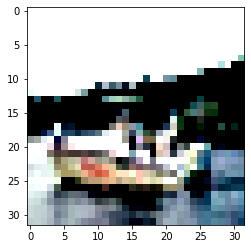

In [23]:
plt.imshow(img_t.permute(1, 2, 0))
plt.show()